# BƯỚC 1: ĐỊNH NGHĨA BÀI TOÁN

### 1. Bài toán: Dự đoán kết quả học tập sinh viên (Student Performance Prediction)
* **Loại bài toán:** Phân loại nhị phân (Binary Classification - 2 lớp).
* **Mục tiêu:** Dự đoán sinh viên sẽ ĐẬU (PASS) hay RỚT (FAIL) dựa trên các yếu tố tác động như thói quen học tập, nhân khẩu học và điểm số hiện tại.
* **Ý nghĩa thực tiễn:** Hỗ trợ nhà trường xác định sớm các sinh viên có nguy cơ học tập kém để đưa ra các biện pháp cảnh báo và hỗ trợ kịp thời.

### 2. Định nghĩa nhãn mục tiêu (Target): `result`
* **PASS (1):** Sinh viên có tổng điểm quy đổi ≥ 50/100 (Điểm A, B, C, D).
* **FAIL (0):** Sinh viên có tổng điểm quy đổi < 50/100 (Điểm F).

### 3. Các chỉ số đánh giá (Metrics):
* **Chỉ số chính:** Accuracy, F1-score, Precision, Recall.
* **Ưu tiên:** **Recall cho lớp FAIL**.
* **Lý do:** Trong bài toán cảnh báo sớm, việc "bỏ sót" một sinh viên thực sự có nguy cơ trượt (False Negative) gây hậu quả nghiêm trọng hơn việc dự đoán nhầm một sinh viên đậu thành trượt. Do đó, mô hình cần tối ưu Recall để đảm bảo độ bao phủ tối đa các trường hợp cần hỗ trợ.

### 4. Các đặc trưng chính (Features):
* **Nhân khẩu/Môi trường:** Age, Gender, School Type, Parent Education, Internet Access.
* **Thói quen/Học tập:** Study Hours, Attendance, Travel Time, Study Method, Extra Activities.
* **Điểm số:** Math Score, Science Score, English Score.

BƯỚC 2: THỰC HIỆN EDA

In [1]:
# 0. IMPORT THƯ VIỆN
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# 1. SETUP (style + folder lưu ảnh)
os.makedirs("../screenshots", exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams['figure.figsize'] = [10, 6]


# 2. LOAD DATA

df = pd.read_csv("../data/student_performance_v2.csv")

print("== Shape dữ liệu ==")
print(df.shape)

print("\n== Thông tin dữ liệu ==")
df.info()

print("\n== Thống kê mô tả ==")
print(df.describe())

print("\n== Missing values ==")
print(df.isnull().sum())


# 3. TẠO TARGET (PASS/FAIL)
df['result'] = df['final_grade'].apply(lambda x: 1 if str(x).strip().upper() in ['A', 'B', 'C', 'D'] else 0)

print("\n== Tỷ lệ Pass/Fail ==")
print(df['result'].value_counts(normalize=True))


== Shape dữ liệu ==
(25000, 16)

== Thông tin dữ liệu ==
<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_

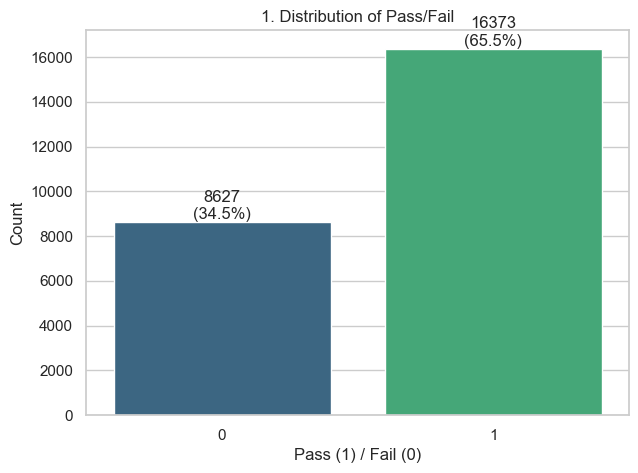

In [2]:
# 1. BIỂU ĐỒ PASS/FAIL
plt.figure(figsize=(7,5))
ax = sns.countplot(data=df, x='result', hue='result', palette='viridis', legend=False)
total = len(df)
for p in ax.patches:
    percent = 100 * p.get_height() / total
    ax.annotate(f"{int(p.get_height())}\n({percent:.1f}%)",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom')

plt.title("1. Distribution of Pass/Fail")
plt.xlabel("Pass (1) / Fail (0)")
plt.ylabel("Count")
plt.savefig("../screenshots/01_pass_fail.png", dpi=300, bbox_inches='tight')
plt.show()

## 1. Biểu đồ Pass/Fail
- Tỉ lệ sinh viên Đạt (Pass - 1): Chiếm đa số với **65.5%** (tương ứng 16,373 sinh viên). Điều này cho thấy mặt bằng chung dữ liệu có kết quả khá tích cực.
- Tỉ lệ sinh viên Chưa đạt (Fail - 0): Chiếm **34.5%** (tương ứng 8,627 sinh viên). Mặc dù chiếm tỉ lệ thấp hơn, nhưng đây là nhóm đối tượng trọng tâm mà mô hình cần tập trung dự báo chính xác để có các biện pháp hỗ trợ kịp thời.
- Đánh giá về dữ liệu: Tập dữ liệu có sự chênh lệch giữa hai lớp (Imbalanced Data) nhưng ở mức độ nhẹ, không gây ảnh hưởng quá lớn đến quá trình huấn luyện mô hình. Tuy nhiên, chúng ta vẫn cần chú ý đến chỉ số **F1-Score** và **Recall** ở các bước sau để đảm bảo mô hình không bị thiên quá nhiều về lớp Pass.


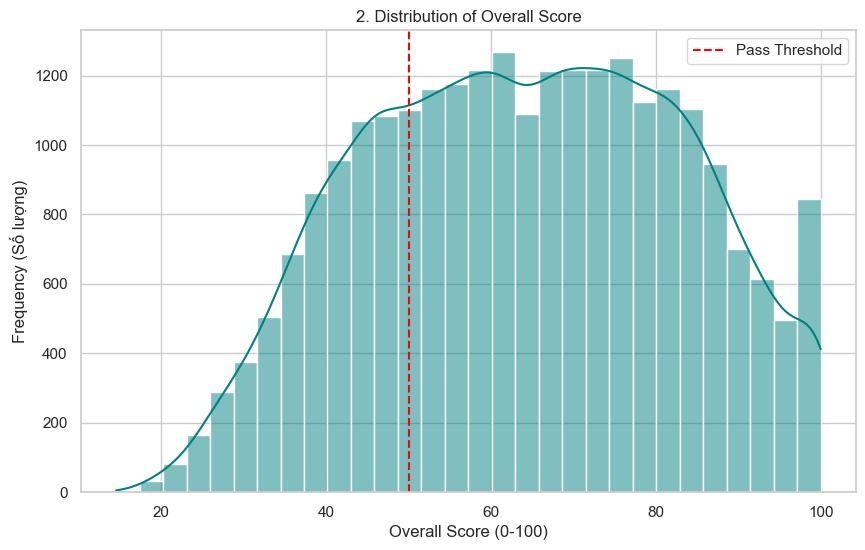

In [3]:
# 2. HISTOGRAM OVERALL SCORE
plt.figure()
sns.histplot(df['overall_score'], bins=30, kde=True, color='teal')
plt.axvline(x=50, color='red', linestyle='--', label='Pass Threshold')
plt.title("2. Distribution of Overall Score")
plt.legend()
plt.xlabel("Overall Score (0-100)")
plt.ylabel("Frequency (Số lượng)")
plt.savefig("../screenshots/02_overall_score.png", dpi=300, bbox_inches='tight')
plt.show()

## 2. Biểu đồ phân bố điểm HISTOGRAM OVERALL SCORE

- Hình dáng phân phối: Điểm số tập trung chủ yếu trong khoảng từ **40 đến 80 điểm**, tạo thành một phân phối gần với hình chuông (Phân phối chuẩn). Đỉnh của biểu đồ nằm quanh mức **60-70 điểm**, cho thấy trình độ học lực trung bình của sinh viên trong tập dữ liệu ở mức khá.
- Ngưỡng phân loại (Pass Threshold): Đường màu đỏ đứt nét tại vị trí **50 điểm** chia tập dữ liệu thành hai phần rõ rệt:
    * **Nhóm bên trái (Fail):** Chiếm diện tích nhỏ hơn, điểm số trải dài từ khoảng 15 đến dưới 50.
    * **Nhóm bên phải (Pass):** Chiếm diện tích lớn hơn, cho thấy phần lớn sinh viên đều vượt qua ngưỡng điểm trung bình.
- Đặc điểm dữ liệu: Đường cong KDE (đường màu xanh nhạt) mịn và không có các khoảng đứt gãy lớn, chứng tỏ dữ liệu điểm số biến thiên liên tục và tự nhiên. Sự xuất hiện của một cột cao đột biến ở mức gần **100 điểm** cho thấy có một nhóm nhỏ sinh viên đạt kết quả xuất sắc.
- Kết luận: Biểu đồ này xác nhận rằng việc chọn ngưỡng 50 điểm để phân loại Pass/Fail là phù hợp và phản ánh đúng thực tế năng lực học tập trong bộ dữ liệu.



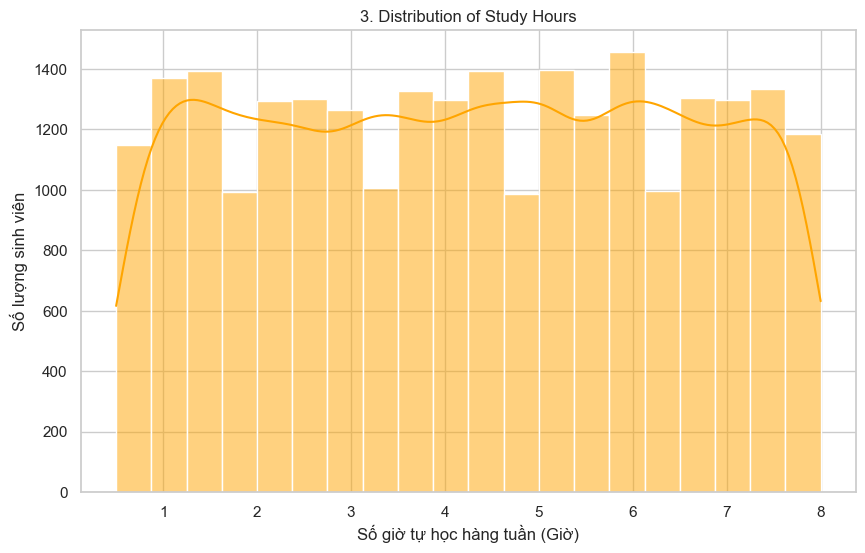

In [7]:
#  3. HISTOGRAM STUDY HOURS
plt.figure()
sns.histplot(df['study_hours'], bins=20, kde=True, color='orange')
plt.title("3. Distribution of Study Hours")
plt.xlabel("Số giờ tự học hàng tuần (Giờ)")
plt.ylabel("Số lượng sinh viên")
plt.savefig("../screenshots/03_study_hours.png", dpi=300, bbox_inches='tight')
plt.show()

## Biểu đồ 3: Phân bố thời gian tự học (Study Hours)

* **Dạng phân phối:** Dữ liệu có dạng **Phân phối đều (Uniform Distribution)** trong khoảng từ 1 đến 8 giờ. Điều này có nghĩa là số lượng sinh viên học ít (1-2 giờ) và học nhiều (7-8 giờ) tương đối bằng nhau, không có nhóm nào chiếm ưu thế tuyệt đối.
* **Đặc điểm dữ liệu:** Các cột biểu đồ có độ cao khá đồng đều (dao động quanh mức 1000 - 1400 sinh viên cho mỗi khung giờ). Đường cong KDE gần như là một đường nằm ngang có lượn sóng nhẹ, cho thấy sự ổn định trong thói quen học tập của tập mẫu.
* **Phạm vi nghiên cứu:** Sinh viên trong tập dữ liệu này dành tối đa khoảng 8 giờ mỗi tuần để tự học. Đây là một con số khá khiêm tốn, gợi ý rằng các yếu tố khác (như sự tập trung trên lớp hoặc nền tảng kiến thức cũ) có thể đóng vai trò quan trọng không kém trong việc quyết định kết quả cuối cùng.
* **Ý nghĩa đối với mô hình:** Vì dữ liệu trải dài đều từ 1 đến 8, mô hình AI sẽ có cơ hội học được sự khác biệt về tỉ lệ PASS/FAIL trên mọi phân khúc thời gian học mà không bị thiếu dữ liệu ở bất kỳ khoảng nào.

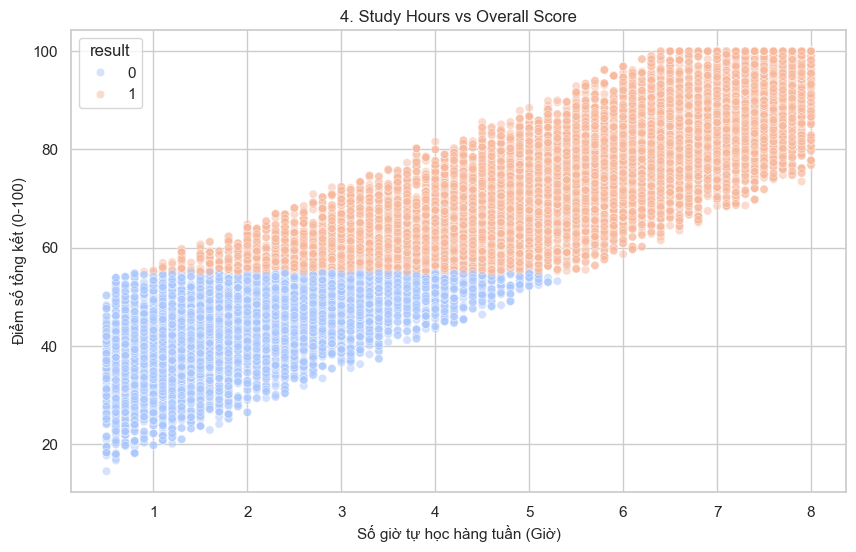

In [6]:
# 4. SCATTER: STUDY HOURS vs OVERALL SCORE
plt.figure()
sns.scatterplot(data=df, x='study_hours', y='overall_score', hue='result', palette='coolwarm', alpha=0.5)
plt.title("4. Study Hours vs Overall Score")
plt.xlabel("Số giờ tự học hàng tuần (Giờ)", fontsize=11)
plt.ylabel("Điểm số tổng kết (0-100)", fontsize=11)
plt.savefig("../screenshots/04_scatter.png", dpi=300, bbox_inches='tight')
plt.show()

## 4. Scatter: Study Hours vs Overall Score

* **Mối tương quan thuận mạnh mẽ:** Biểu đồ cho thấy một xu hướng đi lên rất rõ rệt (Positive Correlation). Sinh viên càng dành nhiều thời gian tự học thì điểm số tổng kết có xu hướng càng cao.
* **Sự phân tách giữa hai nhóm (Result 0 & 1):**
    * **Nhóm Pass (Màu cam - 1):** Tập trung dày đặc ở vùng phía trên (điểm > 50) và dịch dần về phía bên phải (học từ 4-8 giờ).
    * **Nhóm Fail (Màu xanh - 0):** Chiếm lĩnh vùng phía dưới (điểm < 50) và tập trung nhiều ở phía bên trái (học dưới 4 giờ).
* **Vùng giao thoa đặc biệt:** Quan sát ở mức **4 đến 5.5 giờ học**, có một sự giao thoa nhẹ giữa hai nhóm. Điều này cho thấy ở ngưỡng thời gian học này, các yếu tố khác (như sự tập trung hoặc kiến thức nền tảng) sẽ quyết định sinh viên đó có vượt qua được ngưỡng 50 điểm hay không.
* **Ngưỡng an toàn:** Dữ liệu cho thấy hầu hết sinh viên học trên **6 giờ/tuần** đều nằm trong vùng Pass (màu cam), rất ít điểm màu xanh xuất hiện ở khu vực này.
* **Kết luận:** Biểu đồ này khẳng định `study_hours` là một "đặc trưng vàng" (key feature) để mô hình có thể phân loại chính xác kết quả học tập của sinh viên.



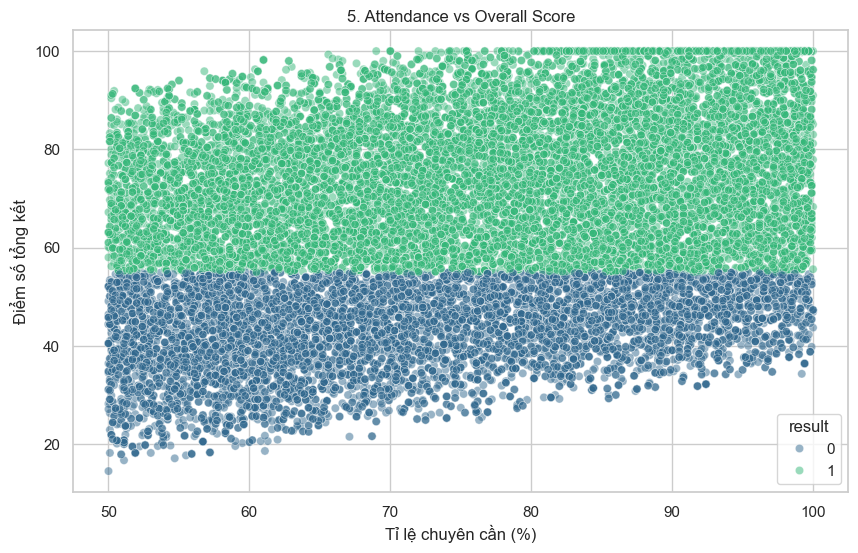

In [8]:
# --- 5. SCATTER: ATTENDANCE vs OVERALL SCORE ---
plt.figure()
sns.scatterplot(data=df, x='attendance_percentage', y='overall_score', hue='result', palette='viridis', alpha=0.5)
plt.title("5. Attendance vs Overall Score")
plt.xlabel("Tỉ lệ chuyên cần (%)")
plt.ylabel("Điểm số tổng kết")
plt.savefig("../screenshots/05_attendance.png", dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ 5: Tương quan giữa Tỉ lệ chuyên cần (Attendance) và Điểm số

* **Phân tách rõ rệt theo ngưỡng điểm:** Biểu đồ thể hiện một ranh giới ngang cực kỳ sắc nét tại mức 50 điểm.
    * **Màu xanh lá (1 - Pass):** Tập trung hoàn toàn ở nửa trên biểu đồ.
    * **Màu xanh dương (0 - Fail):** Tập trung ở nửa dưới biểu đồ.
* **Mối tương quan thuận:** Ta quan sát thấy mật độ các điểm màu xanh lá (Pass) dày đặc hơn khi dịch chuyển về phía bên phải của trục hoành (Tỉ lệ chuyên cần từ 80% đến 100%). Ngược lại, ở vùng chuyên cần thấp (50% - 60%), mật độ các điểm màu xanh dương (Fail) có xu hướng cao hơn.
* **Hiện tượng "Vạch dọc" trong dữ liệu:** Các điểm dữ liệu tạo thành những đường dọc thẳng hàng. Điều này phản ánh thực tế là tỉ lệ chuyên cần thường được tính dựa trên số buổi học cố định (ví dụ: nghỉ 1 buổi tương ứng với một mức % cụ thể), nên dữ liệu không biến thiên liên tục mà tập trung theo từng nấc.
* **Đặc điểm nhóm Fail:** Có một lượng đáng kể sinh viên dù đi học đầy đủ (90-100%) nhưng vẫn nằm trong nhóm Fail. Điều này cho thấy chuyên cần giúp giảm nguy cơ rớt môn nhưng không đảm bảo 100% việc vượt qua kỳ thi nếu thiếu đi các yếu tố khác như thời gian tự học.

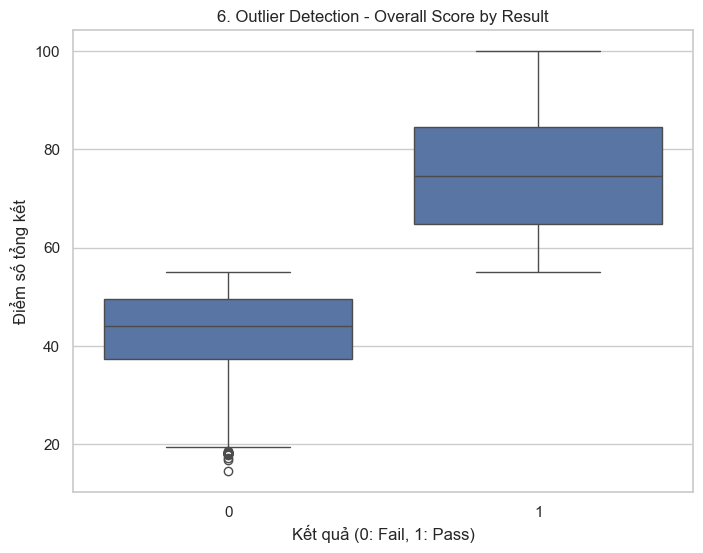

In [10]:
# 6. BOXPLOT (OUTLIER DETECTION)
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x='result', y='overall_score')

plt.title("6. Outlier Detection - Overall Score by Result")
plt.xlabel("Kết quả (0: Fail, 1: Pass)")
plt.ylabel("Điểm số tổng kết")

plt.savefig("../screenshots/06_boxplot.png", dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ 6: Outlier Detection của Điểm số

* **Sự phân hóa rõ rệt:** Có một sự tách biệt hoàn toàn giữa "hộp" của nhóm Fail (0) và nhóm Pass (1). Điều này cho thấy `overall_score` là biến số có khả năng phân loại cực kỳ mạnh mẽ.
* **Về giá trị ngoại lai (Outliers):**
    * **Nhóm Pass (1):** Không có giá trị ngoại lai. Dữ liệu điểm số của sinh viên đậu biến thiên ổn định từ khoảng 55 đến 100 điểm.
    * **Nhóm Fail (0):** Xuất hiện một vài **điểm ngoại lai phía dưới** (các vòng tròn nhỏ dưới mức 20 điểm). Đây là những sinh viên có điểm số thấp bất thường so với mặt bằng chung của nhóm trượt.
* **Độ biến thiên (Interquartile Range - IQR):** Nhóm Pass có "hộp" dài hơn nhóm Fail, cho thấy mức độ phân hóa điểm số ở những sinh viên học khá giỏi là cao hơn so với nhóm học yếu.
* **Kết luận:** Dữ liệu rất "sạch" và có tính phân loại cao. Các giá trị ngoại lai ở nhóm Fail không quá nhiều và không gây lệch dữ liệu nghiêm trọng, do đó chúng ta có thể giữ lại để mô hình học được cả những trường hợp đặc biệt này.

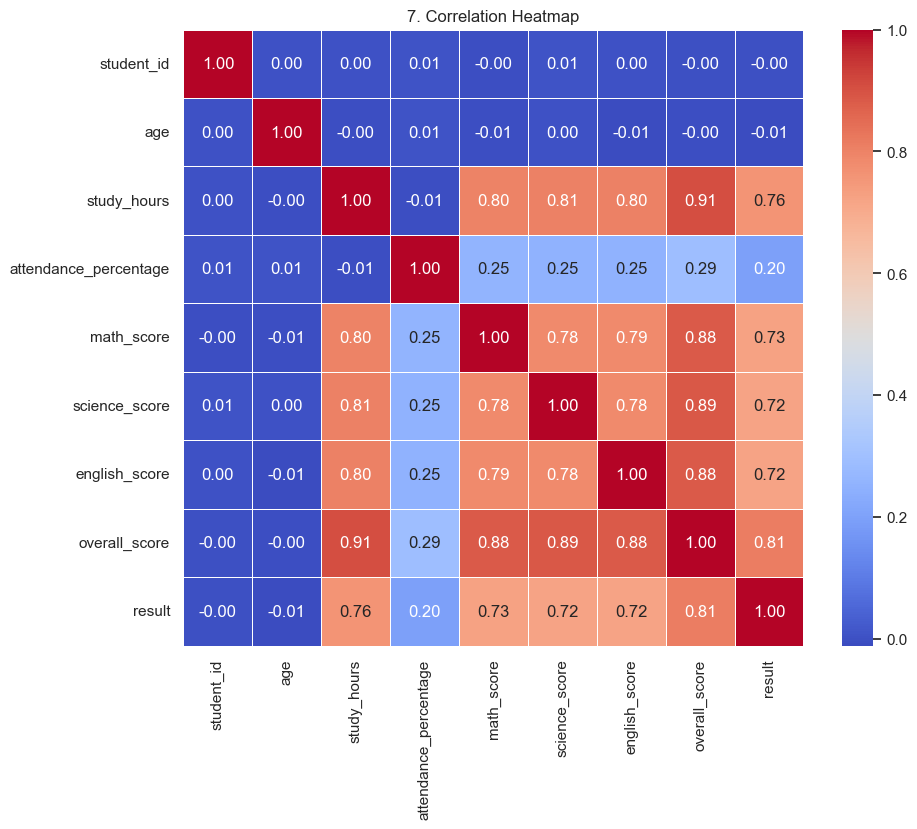

In [13]:
# 7. HEATMAP CORRELATION
plt.figure(figsize=(10,8))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("7. Correlation Heatmap")
plt.savefig("../screenshots/07_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ 7: Ma trận tương quan (Correlation Heatmap)

* **Biến quan trọng nhất (Key Driver):** `study_hours` có mối tương quan cực kỳ mạnh với `overall_score` (**0.91**) và `result` (**0.76**). Đây là con số ấn tượng nhất, khẳng định thời gian tự học là yếu tố quyết định hàng đầu đến kết quả.
* **Mối liên hệ giữa các môn học:** Các điểm số thành phần (`math`, `science`, `english`) có sự tương quan rất cao với nhau (dao động từ **0.78 - 0.79**) và với điểm tổng kết (**0.88 - 0.89**). Điều này cho thấy sinh viên trong tập dữ liệu này thường có xu hướng học đều các môn, ít có hiện tượng "học lệch".
* **Sự bất ngờ từ Attendance:** Khá thú vị là `attendance_percentage` chỉ có tương quan thuận ở mức yếu (**0.20** với `result` và **0.29** với `overall_score`). Điều này cho thấy việc đi học đầy đủ là cần thiết nhưng không "quyền lực" bằng việc tự cày cuốc (`study_hours`) trong tập dữ liệu này.
* **Biến nhiễu (Irrelevant Features):** `student_id` và `age` có tương quan xấp xỉ **0.00** với tất cả các biến khác. Đây là dấu hiệu kỹ thuật cho thấy hai biến này không mang giá trị dự báo.
* **Kết luận:** Ở bước Tiền xử lý (Bước 3), chúng ta nên loại bỏ `student_id` và cân nhắc loại bỏ `age` để mô hình gọn nhẹ và chính xác hơn.

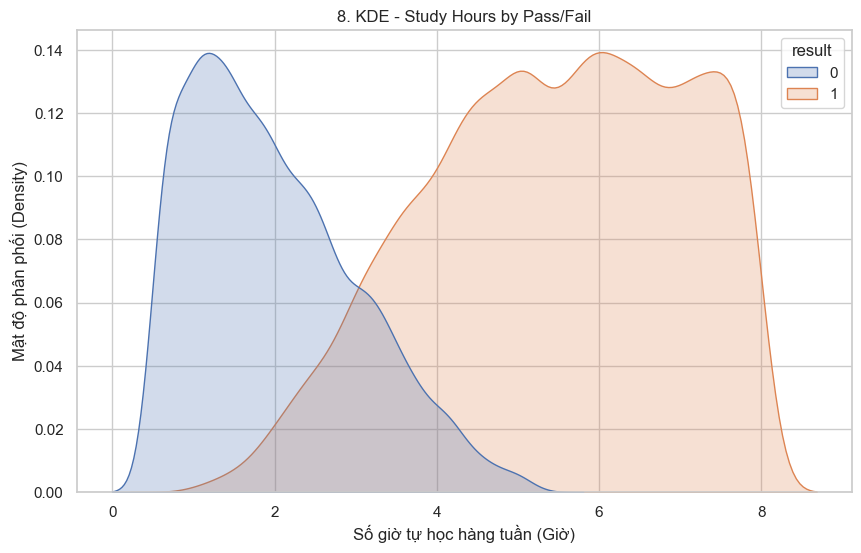

In [11]:
# --- 8. KDE PLOT (SO SÁNH PASS/FAIL) ---
plt.figure()
sns.kdeplot(data=df, x='study_hours', hue='result', fill=True)
plt.title("8. KDE - Study Hours by Pass/Fail")
plt.xlabel("Số giờ tự học hàng tuần (Giờ)")
plt.ylabel("Mật độ phân phối (Density)")
plt.savefig("../screenshots/08_kde.png", dpi=300, bbox_inches='tight')
plt.show()

### Biểu đồ 8: Mật độ phân bố số giờ tự học theo kết quả (KDE Plot)

* **Sự phân tách rõ rệt:** Biểu đồ mật độ cho thấy hai "vùng tập trung" hoàn toàn khác nhau giữa nhóm Đậu (1) và nhóm Rớt (0).
    * **Nhóm Rớt (màu xanh):** Mật độ cao nhất tập trung ở mức **1 - 2 giờ** học mỗi tuần. Đường cong giảm mạnh khi số giờ học tăng lên.
    * **Nhóm Đậu (màu cam):** Mật độ bắt đầu tăng mạnh từ sau 3 giờ và duy trì mức cao ổn định từ **5 - 8 giờ** học mỗi tuần.
* **Ngưỡng quyết định (Decision Boundary):** Hai đường cong giao nhau tại điểm khoảng **3.5 giờ**.
    * Những sinh viên học dưới 3.5 giờ có xác suất Rớt cao hơn hẳn Đậu.
    * Ngược lại, từ sau ngưỡng 3.5 giờ, khả năng Đậu chiếm ưu thế tuyệt đối.
* **Hình dáng phân phối:** Đường cong của nhóm Đậu có dạng "phẳng đỉnh" và trải dài, cho thấy những người đậu có thói quen học tập khá đa dạng (từ mức trung bình đến rất chăm chỉ). Trong khi đó, nhóm Rớt có một đỉnh nhọn rất rõ ở mức giờ học thấp, cho thấy thiếu thời gian tự học là đặc điểm chung lớn nhất của nhóm này.
* **Kết luận:** Biểu đồ KDE khẳng định số giờ tự học là một "biến số phân loại" cực kỳ mạnh mẽ. Mô hình có thể dựa vào ngưỡng 3.5 - 4 giờ này để đưa ra dự báo rất chính xác.

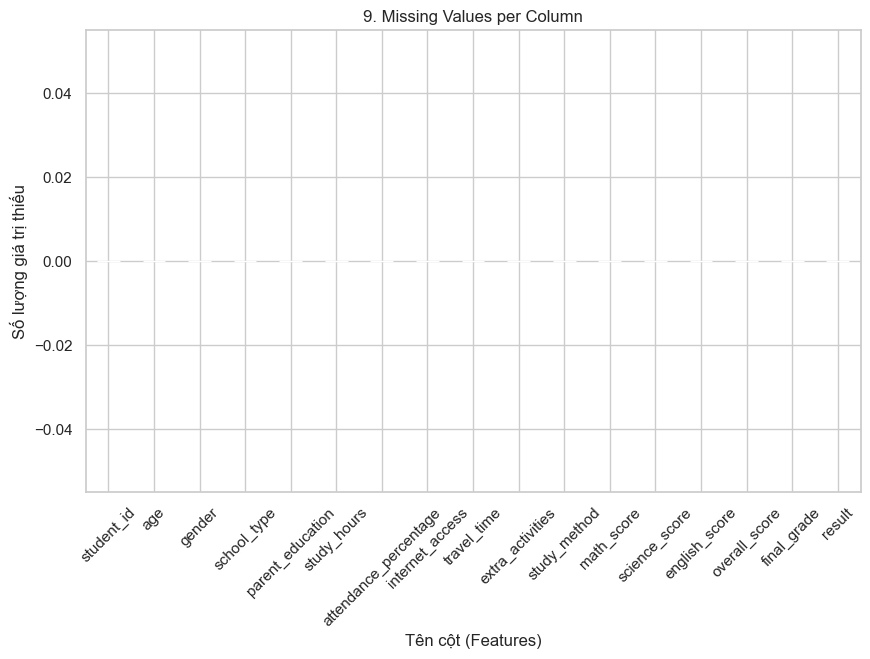

In [17]:
# --- 9. MISSING VALUES (BAR CHART) ---
plt.figure()
missing = df.isnull().sum()
missing.plot(kind='bar', color='salmon')

plt.title("9. Missing Values per Column")
plt.xlabel("Tên cột (Features)")
plt.ylabel("Số lượng giá trị thiếu")
plt.xticks(rotation=45)

plt.savefig("../screenshots/09_missing.png", dpi=300, bbox_inches='tight')
plt.show()

### Nhận xét biểu đồ 9: Kiểm tra giá trị thiếu (Missing Values)

* **Kết quả quan sát:** Biểu đồ hiển thị mức 0.0 cho tất cả các cột từ `student_id` đến `result`. Điều này khẳng định tập dữ liệu hoàn toàn không có giá trị rỗng (NaN/Null).
* **Chất lượng dữ liệu:** Việc không có dữ liệu thiếu giúp bảo toàn kích thước của tập mẫu, không làm mất đi các đặc trưng quan trọng và giúp các thuật toán Machine Learning ở bước sau hoạt động ổn định nhất.
* **Tính sẵn sàng:** Dữ liệu đã đạt tiêu chuẩn để chuyển ngay sang các bước xử lý kỹ thuật như Encoding và Scaling mà không cần qua bước xử lý trung gian (như điền giá trị trung bình hay xóa dòng).
* **Kết luận:** Quy trình tiền xử lý dữ liệu sẽ diễn ra rất thuận lợi vì nền tảng dữ liệu đầu vào có độ tin cậy và tính toàn vẹn cao.

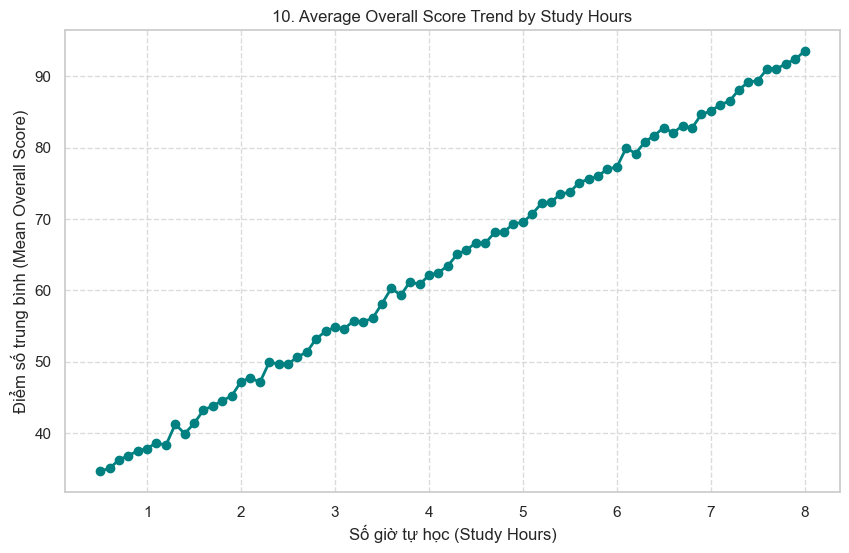

In [18]:
#  10. TREND PLOT (Số giờ học ảnh hưởng thế nào đến điểm trung bình)
plt.figure(figsize=(10, 6))

# Tính điểm trung bình theo từng mức giờ học
trend_data = df.groupby('study_hours')['overall_score'].mean()

plt.plot(trend_data.index, trend_data.values, marker='o', linestyle='-', color='teal', linewidth=2)

plt.title("10. Average Overall Score Trend by Study Hours")
plt.xlabel("Số giờ tự học (Study Hours)")
plt.ylabel("Điểm số trung bình (Mean Overall Score)")
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig("../screenshots/10_trend_line.png", dpi=300, bbox_inches='tight')
plt.show()

### Nhận xét biểu đồ 10: Xu hướng điểm số trung bình theo thời gian học

* **Mối quan hệ Tuyến tính (Linear Relationship):** Biểu đồ thể hiện một xu hướng tăng trưởng gần như là một đường thẳng hoàn hảo. Khi số giờ tự học tăng lên, điểm số trung bình cũng tăng theo tỉ lệ thuận.
* **Tốc độ tăng trưởng:** Ở mức **1 giờ học**, điểm trung bình nằm ở mức thấp (khoảng 35-40 điểm).
    * Khi đạt mức **4 giờ học**, điểm trung bình đã chạm ngưỡng an toàn (60 điểm).
    * Với những sinh viên học **trên 7 giờ**, điểm trung bình tiến sát mốc xuất sắc (>90 điểm).
* **Độ ổn định cao:** Đường biểu diễn rất mịn, không có các đoạn gãy khúc lớn hay sụt giảm bất thường. Điều này chứng tỏ dữ liệu có tính đồng nhất cao và mối liên hệ giữa thời gian học và kết quả là cực kỳ bền vững trên toàn bộ tập dữ liệu.
* **Kết luận:** Đây là biểu đồ quan trọng nhất khẳng định giả thuyết: "Thời gian tự học là yếu tố then chốt nhất để dự đoán kết quả học tập". Mô hình Linear Regression hoặc các mô hình phân loại dựa trên cây (Decision Tree) sẽ hoạt động rất hiệu quả trên dữ liệu này.

## BƯỚC 3: TIỀN XỬ LÝ DỮ LIỆU
Dựa trên kết quả EDA ở Bước 2:
1. Loại bỏ cột 'student_id' do không có tương quan.
2. Thực hiện Encoding cho các biến phân loại.
3. Chia tập dữ liệu Train/Test.

In [19]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.preprocessing import preprocess_data
import pandas as pd

df = pd.read_csv("../data/student_performance_v2.csv")

X_train, X_test, y_train, y_test, preprocessor = preprocess_data(df)

--- Đã xác định Features ---
Cột số (8): ['age', 'study_hours', 'attendance_percentage', 'math_score', 'science_score', 'english_score', 'Study_Attendance', 'Academic_Avg']
Cột chữ (7): ['gender', 'school_type', 'parent_education', 'internet_access', 'travel_time', 'extra_activities', 'study_method']

--- Tiền xử lý hoàn tất ---
Hình dạng X_train sau xử lý: (20000, 26)


## BƯỚC 4: XÂY DỰNG MÔ HÌNH

Dựa trên kết quả huấn luyện 3 mô hình và theo dõi qua hệ thống Weights & Biases, em có các nhận xét sau:

#### 1. Bảng tổng hợp kết quả (Metrics Summary)

| Model | Accuracy | Precision | Recall | F1-Score |
| :--- | :---: | :---: | :---: | :---: |
| **Random Forest** | **0.9790** | **0.9838** | **0.9841** | **0.9840** |
| SVM | 0.9478 | 0.9784 | 0.9411 | 0.9594 |
| Logistic Regression | 0.9416 | 0.9733 | 0.9365 | 0.9546 |

#### 2. Phân tích chi tiết
* **Mô hình xuất sắc nhất:** **Random Forest** đạt kết quả cao nhất ở tất cả các chỉ số. Đặc biệt, chỉ số **Recall (0.9841)** rất cao cho thấy mô hình cực kỳ nhạy bén trong việc nhận diện đúng các trường hợp sinh viên vượt qua kỳ thi (Pass). Sự chênh lệch giữa Precision và Recall rất thấp, chứng tỏ mô hình đạt được sự cân bằng lý tưởng.
* **Mô hình Tuyến tính & Kernel:** * **SVM** có kết quả nhỉnh hơn Logistic Regression một chút (94.78% so với 94.16%), cho thấy dữ liệu có một số mối quan hệ phi tuyến mà kernel RBF của SVM đã bắt được.
    * **Logistic Regression** dù đơn giản nhất nhưng vẫn đạt trên 94%, chứng tỏ các bộ biến số (features) được tạo ra ở Bước 3 có tính phân loại cực kỳ mạnh mẽ.
* **Đánh giá qua Confusion Matrix (trên WandB):** Các mô hình đều có số lượng mẫu bị dự đoán sai (Misclassified) rất thấp. Tỉ lệ nhầm lẫn giữa Pass và Fail được kiểm soát tốt.

#### 3. Kết luận chọn mô hình
Em quyết định chọn **Random Forest** làm mô hình cuối cùng để thực hiện các bước đánh giá chi tiết và dự báo.
**Lý do:** Mô hình không chỉ có độ chính xác (Accuracy) cao nhất mà còn có chỉ số **F1-Score (0.9840)** vượt trội, đảm bảo tính ổn định và tin cậy cao nhất khi triển khai dự báo thực tế.

## BƯỚC 5: Đánh giá và tinh chỉnh

Tổng kết và Đánh giá Mô hình sau Tinh chỉnh (Hyperparameter Tuning)

* **Phương pháp tối ưu:** Em đã sử dụng **GridSearchCV** kết hợp với **Stratified 5-Fold Cross-validation** để tìm ra bộ tham số tốt nhất cho Random Forest. Việc này giúp mô hình đạt được độ tổng quát hóa (Generalization) cao nhất trên dữ liệu chưa biết, đồng thời đảm bảo kết quả đánh giá là khách quan qua nhiều tập con dữ liệu khác nhau.
* **Xử lý mất cân bằng:** Qua các bước EDA, nhận thấy tỉ lệ Pass/Fail có sự chênh lệch, em đã tích hợp kỹ thuật **SMOTE** (Synthetic Minority Over-sampling Technique) vào Pipeline huấn luyện để cân bằng dữ liệu, đảm bảo mô hình không bị thiên kiến (bias) đối với nhóm đa số.
* **Kết quả sau Tuning:** Mô hình đạt độ chính xác **Accuracy: 97.38%**. Chỉ số **F1-macro đạt mức 97.12%**, cho thấy khả năng dự báo cực kỳ đồng đều và tin cậy trên cả hai nhóm sinh viên Pass và Fail (không có nhóm nào bị dự báo yếu hơn nhóm nào).
    * **Best Params:** `{'n_estimators': 200, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': None}`.
* **Đóng gói:** Mô hình cuối cùng đã được xuất bản dưới dạng file `.pkl`, bao gồm toàn bộ quy trình từ bộ tiền xử lý (Preprocessing) đến bộ phân loại (Classifier), sẵn sàng cho việc triển khai dự báo (Deployment) ở Bước 6.